# Localização e IoU — Notebook 1/4 (versão 2h)

## Aula: Localização, Detecção e Segmentação de Objetos

**Prof. Dr. Rooney Coelho** — Aprendizagem de Máquina (CDIA)

### Objetivo

Compreender as representações de caixas delimitadoras (*bounding boxes*) e a métrica de Intersecção sobre União (IoU), e treinar do zero um modelo simples que prevê, simultaneamente, **a classe** e **a caixa** de um único objeto em imagens sintéticas — preparando o terreno conceitual para os detectores multi-objeto dos próximos notebooks.

### O que vamos cobrir

1. Representações de caixas: `xyxy`, `cxcywh` e formato normalizado.
2. Conversões entre formatos e teste de consistência.
3. Métrica IoU: definição, implementação e visualização.
4. Construção de um *dataset* sintético com uma forma por imagem.
5. Modelo CNN com duas cabeças (classe + caixa) e perda multi-tarefa.
6. Treino, avaliação (acurácia + IoU médio) e exercício.

### Pré-requisitos

PyTorch básico (`nn.Module`, `DataLoader`, *loops* de treino), CNNs e noções de classificação multi-classe. O notebook é totalmente *offline* (dados sintéticos) e roda em CPU, MPS ou CUDA.

In [1]:
# ============================================================
# 1. Importações e seleção de dispositivo
# ============================================================
import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def selecionar_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


SEMENTE = 42
random.seed(SEMENTE)
np.random.seed(SEMENTE)
torch.manual_seed(SEMENTE)

device = selecionar_device()
print(f"PyTorch: {torch.__version__}")
print(f"Dispositivo em uso: {device}")

PyTorch: 2.12.0
Dispositivo em uso: mps


## 2. Representações de caixa delimitadora

Uma caixa pode ser descrita em `xyxy` (cantos superior-esquerdo e inferior-direito: `x1, y1, x2, y2`) ou em `cxcywh` (centro e dimensões: `cx, cy, w, h`); em ambos os casos os valores podem estar em **pixels** ou **normalizados** (0–1) pelas dimensões da imagem, e a conversão entre essas representações é trivial e bijetora.

In [2]:
def xyxy_para_cxcywh(box: torch.Tensor) -> torch.Tensor:
    """Converte caixas (..., 4) de xyxy para cxcywh."""
    x1, y1, x2, y2 = box.unbind(-1)
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    w = (x2 - x1)
    h = (y2 - y1)
    return torch.stack([cx, cy, w, h], dim=-1)


def cxcywh_para_xyxy(box: torch.Tensor) -> torch.Tensor:
    """Converte caixas (..., 4) de cxcywh para xyxy."""
    cx, cy, w, h = box.unbind(-1)
    x1 = cx - w / 2
    y1 = cy - h / 2
    x2 = cx + w / 2
    y2 = cy + h / 2
    return torch.stack([x1, y1, x2, y2], dim=-1)


# Teste ida-e-volta
caixas_xyxy = torch.tensor([[10.0, 20.0, 50.0, 80.0],
                            [0.1,  0.2,  0.7,  0.9],
                            [5.0,  5.0, 25.0, 35.0]])
ida = xyxy_para_cxcywh(caixas_xyxy)
volta = cxcywh_para_xyxy(ida)
assert torch.allclose(volta, caixas_xyxy, atol=1e-6), "Conversão não é bijetora!"
print("Conversões xyxy <-> cxcywh OK.")
print("cxcywh =", ida)

Conversões xyxy <-> cxcywh OK.
cxcywh = tensor([[30.0000, 50.0000, 40.0000, 60.0000],
        [ 0.4000,  0.5500,  0.6000,  0.7000],
        [15.0000, 20.0000, 20.0000, 30.0000]])


## 3. Intersecção sobre União (IoU)

Dadas duas caixas $A$ e $B$, a IoU é definida como
$$\mathrm{IoU}(A, B) = \frac{|A \cap B|}{|A \cup B|} = \frac{\text{área da interseção}}{\text{área}(A) + \text{área}(B) - \text{área da interseção}}.$$
Vale entre 0 (sem sobreposição) e 1 (caixas idênticas) e é a métrica padrão para avaliar localização.

In [3]:
def iou(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """IoU entre duas caixas xyxy (broadcast por lote suportado)."""
    x1 = torch.maximum(a[..., 0], b[..., 0])
    y1 = torch.maximum(a[..., 1], b[..., 1])
    x2 = torch.minimum(a[..., 2], b[..., 2])
    y2 = torch.minimum(a[..., 3], b[..., 3])
    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)
    area_a = (a[..., 2] - a[..., 0]).clamp(min=0) * (a[..., 3] - a[..., 1]).clamp(min=0)
    area_b = (b[..., 2] - b[..., 0]).clamp(min=0) * (b[..., 3] - b[..., 1]).clamp(min=0)
    uniao = area_a + area_b - inter
    return torch.where(uniao > 0, inter / uniao, torch.zeros_like(inter))


# Testes rápidos
c1 = torch.tensor([0.0, 0.0, 10.0, 10.0])
c2 = torch.tensor([0.0, 0.0, 10.0, 10.0])
c3 = torch.tensor([20.0, 20.0, 30.0, 30.0])
c4 = torch.tensor([5.0, 5.0, 15.0, 15.0])

print(f"Idênticas:   IoU = {iou(c1, c2).item():.4f}  (esperado 1.0)")
print(f"Disjuntas:   IoU = {iou(c1, c3).item():.4f}  (esperado 0.0)")
# c1 ∩ c4 = [5,5,10,10] -> 25; áreas 100+100; união 175 -> 25/175 ≈ 0.1429
print(f"Parcial:     IoU = {iou(c1, c4).item():.4f}  (esperado ~0.1429)")

Idênticas:   IoU = 1.0000  (esperado 1.0)
Disjuntas:   IoU = 0.0000  (esperado 0.0)
Parcial:     IoU = 0.1429  (esperado ~0.1429)


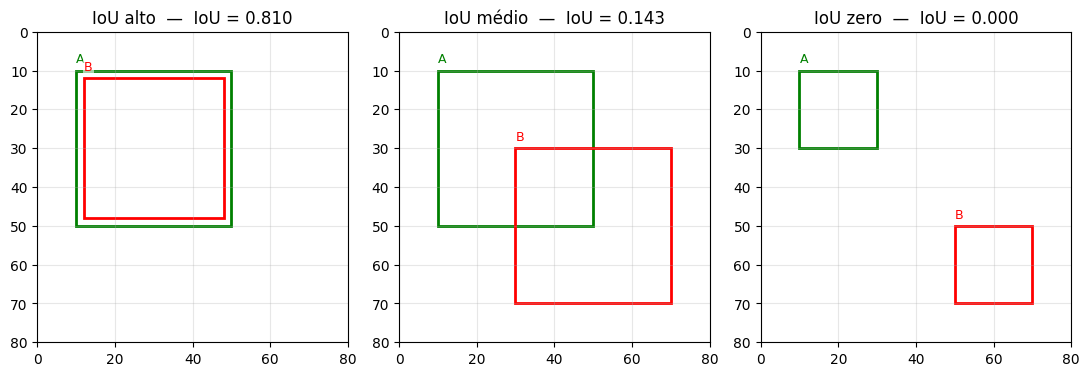

In [4]:
# ============================================================
# 4. Visualizando diferentes níveis de IoU
# ============================================================
def desenhar_caixa(ax, caixa, cor, rotulo=None):
    """Desenha uma caixa xyxy em pixels num eixo matplotlib."""
    x1, y1, x2, y2 = [float(v) for v in caixa]
    ret = Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2,
                    edgecolor=cor, facecolor="none")
    ax.add_patch(ret)
    if rotulo is not None:
        ax.text(x1, y1 - 2, rotulo, color=cor, fontsize=9,
                bbox=dict(facecolor="white", alpha=0.6, pad=1, edgecolor="none"))


pares = [
    (torch.tensor([10.0, 10.0, 50.0, 50.0]), torch.tensor([12.0, 12.0, 48.0, 48.0]), "IoU alto"),
    (torch.tensor([10.0, 10.0, 50.0, 50.0]), torch.tensor([30.0, 30.0, 70.0, 70.0]), "IoU médio"),
    (torch.tensor([10.0, 10.0, 30.0, 30.0]), torch.tensor([50.0, 50.0, 70.0, 70.0]), "IoU zero"),
]

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, (a, b, titulo) in zip(axes, pares):
    ax.set_xlim(0, 80); ax.set_ylim(80, 0); ax.set_aspect("equal")
    desenhar_caixa(ax, a, "green", "A")
    desenhar_caixa(ax, b, "red", "B")
    ax.set_title(f"{titulo}  —  IoU = {iou(a, b).item():.3f}")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Um *dataset* sintético com um objeto por imagem

Para focar nos conceitos de localização sem distrações, vamos gerar imagens 3×64×64 contendo **uma única forma geométrica** (quadrado, círculo ou triângulo) em posição, tamanho e cor aleatórios. A caixa real é conhecida exatamente — ideal para validar perdas e métricas.

In [5]:
class DatasetObjetoUnico(Dataset):
    """Gera imagens 3x64x64 com uma forma (quadrado, círculo, triângulo)."""

    NOMES_CLASSE = ["quadrado", "círculo", "triângulo"]

    def __init__(self, n: int, tamanho: int = 64, semente: int = 0):
        self.n = n
        self.tamanho = tamanho
        self.rng = np.random.default_rng(semente)
        # Pré-sortear parâmetros garante reprodutibilidade independente da ordem.
        self.amostras = [self._sortear() for _ in range(n)]

    def _sortear(self):
        classe = int(self.rng.integers(0, 3))
        lado_min = self.tamanho // 6
        lado_max = self.tamanho // 2
        w = int(self.rng.integers(lado_min, lado_max))
        h = int(self.rng.integers(lado_min, lado_max))
        x1 = int(self.rng.integers(0, self.tamanho - w))
        y1 = int(self.rng.integers(0, self.tamanho - h))
        cor = self.rng.uniform(0.4, 1.0, size=3).astype(np.float32)
        cor_fundo = self.rng.uniform(0.0, 0.3, size=3).astype(np.float32)
        return classe, x1, y1, w, h, cor, cor_fundo

    def __len__(self):
        return self.n

    def _desenhar(self, classe, x1, y1, w, h, cor, cor_fundo):
        T = self.tamanho
        img = np.empty((3, T, T), dtype=np.float32)
        for c in range(3):
            img[c, :, :] = cor_fundo[c]
        yy, xx = np.mgrid[0:T, 0:T]
        if classe == 0:  # quadrado
            mascara = (xx >= x1) & (xx < x1 + w) & (yy >= y1) & (yy < y1 + h)
        elif classe == 1:  # círculo (elipse inscrita na caixa)
            cx = x1 + w / 2
            cy = y1 + h / 2
            rx = w / 2
            ry = h / 2
            mascara = ((xx - cx) ** 2) / (rx ** 2 + 1e-6) + ((yy - cy) ** 2) / (ry ** 2 + 1e-6) <= 1.0
        else:  # triângulo (vértices: topo-centro, base-esq, base-dir)
            vx = np.array([x1 + w / 2, x1, x1 + w])
            vy = np.array([y1, y1 + h, y1 + h])
            # Coordenadas baricêntricas
            den = (vy[1] - vy[2]) * (vx[0] - vx[2]) + (vx[2] - vx[1]) * (vy[0] - vy[2]) + 1e-6
            l1 = ((vy[1] - vy[2]) * (xx - vx[2]) + (vx[2] - vx[1]) * (yy - vy[2])) / den
            l2 = ((vy[2] - vy[0]) * (xx - vx[2]) + (vx[0] - vx[2]) * (yy - vy[2])) / den
            l3 = 1.0 - l1 - l2
            mascara = (l1 >= 0) & (l2 >= 0) & (l3 >= 0)
        for c in range(3):
            img[c][mascara] = cor[c]
        return img

    def __getitem__(self, idx):
        classe, x1, y1, w, h, cor, cor_fundo = self.amostras[idx]
        img = self._desenhar(classe, x1, y1, w, h, cor, cor_fundo)
        # caixa em cxcywh normalizada
        T = self.tamanho
        cx = (x1 + w / 2) / T
        cy = (y1 + h / 2) / T
        wn = w / T
        hn = h / T
        caixa = np.array([cx, cy, wn, hn], dtype=np.float32)
        return (torch.from_numpy(img),
                torch.tensor(classe, dtype=torch.long),
                torch.from_numpy(caixa))


ds_treino = DatasetObjetoUnico(n=2000, semente=1)
ds_teste = DatasetObjetoUnico(n=400, semente=2)
print(f"Treino: {len(ds_treino)} amostras  |  Teste: {len(ds_teste)} amostras")
img0, cls0, cx0 = ds_treino[0]
print(f"Exemplo 0 -> img {tuple(img0.shape)} {img0.dtype}  classe={cls0.item()} ({DatasetObjetoUnico.NOMES_CLASSE[cls0.item()]})  caixa(cxcywh)={cx0.tolist()}")

Treino: 2000 amostras  |  Teste: 400 amostras


Exemplo 0 -> img (3, 64, 64) torch.float32  classe=1 (círculo)  caixa(cxcywh)=[0.7890625, 0.21875, 0.328125, 0.40625]


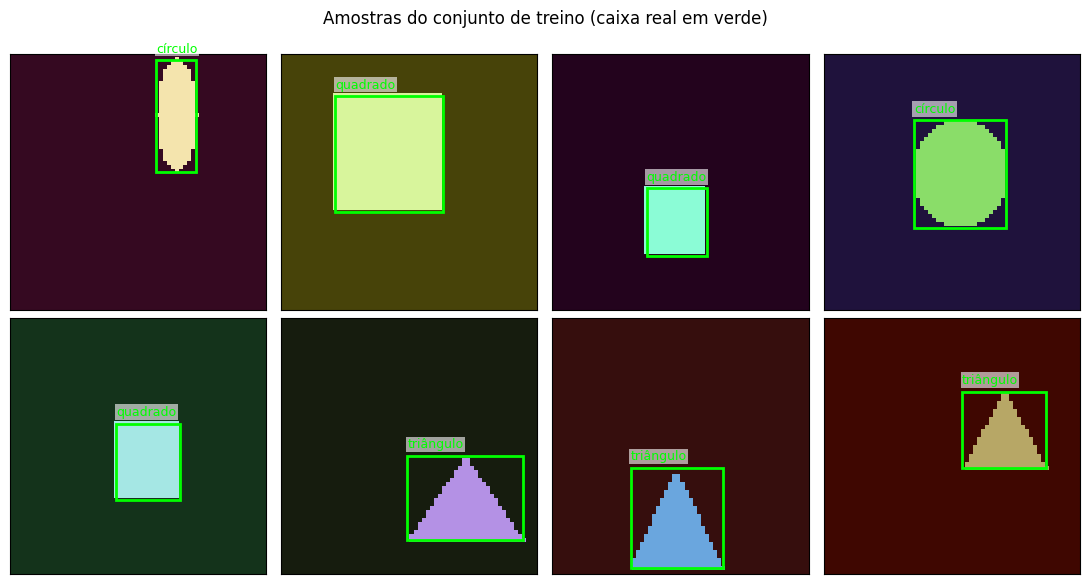

In [6]:
# ============================================================
# 6. Visualizando amostras com caixa real
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(11, 6))
for ax, idx in zip(axes.flat, np.random.choice(len(ds_treino), size=8, replace=False)):
    img, cls, caixa_cxcywh = ds_treino[idx]
    img_np = img.permute(1, 2, 0).numpy()  # H,W,3
    ax.imshow(np.clip(img_np, 0, 1))
    # caixa em pixels (xyxy)
    T = ds_treino.tamanho
    caixa_px = cxcywh_para_xyxy(caixa_cxcywh * T)
    desenhar_caixa(ax, caixa_px, "lime", DatasetObjetoUnico.NOMES_CLASSE[cls.item()])
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Amostras do conjunto de treino (caixa real em verde)")
plt.tight_layout()
plt.show()

## 7. Modelo: *backbone* CNN com duas cabeças

A arquitetura combina um pequeno *backbone* convolucional, que extrai uma representação compacta da imagem, com **duas cabeças lineares**: uma para a classe (3 *logits*) e outra para a caixa (4 valores em `cxcywh` normalizados, passados por `sigmoid` para ficarem em 0–1).

In [7]:
class Localizador(nn.Module):
    def __init__(self, n_classes: int = 3, canais: int = 32):
        super().__init__()

        def bloco(c_in, c_out):
            return nn.Sequential(
                nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(c_out),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.backbone = nn.Sequential(
            bloco(3, canais),         # 64 -> 32
            bloco(canais, canais * 2),    # 32 -> 16
            bloco(canais * 2, canais * 4),  # 16 -> 8
            bloco(canais * 4, canais * 8),  # 8 -> 4
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        c_final = canais * 8
        self.cabeca_classe = nn.Linear(c_final, n_classes)
        self.cabeca_caixa = nn.Linear(c_final, 4)

    def forward(self, x):
        z = self.backbone(x)
        z = self.gap(z).flatten(1)
        logits = self.cabeca_classe(z)
        caixa = torch.sigmoid(self.cabeca_caixa(z))  # cxcywh em [0,1]
        return logits, caixa


modelo = Localizador().to(device)
n_param = sum(p.numel() for p in modelo.parameters())
print(modelo)
print(f"Parâmetros treináveis: {n_param:,}")

Localizador(
  (backbone): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padd

In [8]:
# ============================================================
# 8. Perda multi-tarefa: classificação + regressão
# ============================================================
def perda_multitarefa(logits, caixa_prev, y_classe, y_caixa, lam: float = 1.0):
    """CrossEntropy para a classe + SmoothL1 para a caixa, combinadas por lambda."""
    perda_cls = F.cross_entropy(logits, y_classe)
    perda_box = F.smooth_l1_loss(caixa_prev, y_caixa)
    perda_total = perda_cls + lam * perda_box
    return perda_total, perda_cls.detach(), perda_box.detach()


# Teste rápido do shape
xb, yb_cls, yb_box = next(iter(DataLoader(ds_treino, batch_size=4)))
xb, yb_cls, yb_box = xb.to(device), yb_cls.to(device), yb_box.to(device)
with torch.no_grad():
    lg, bp = modelo(xb)
p, pc, pb = perda_multitarefa(lg, bp, yb_cls, yb_box)
print(f"perda total={p.item():.4f}  cls={pc.item():.4f}  box={pb.item():.4f}")

perda total=1.0892  cls=1.0575  box=0.0316


## 9. Loop de treino

Treinamos por algumas dezenas de épocas com Adam; o tempo total é de poucos minutos em CPU/MPS.

In [9]:
TAMANHO_LOTE = 64
EPOCAS = 18
LAM = 1.0
TAXA_APRENDIZADO = 1e-3

dl_treino = DataLoader(ds_treino, batch_size=TAMANHO_LOTE, shuffle=True, num_workers=0)
dl_teste = DataLoader(ds_teste, batch_size=TAMANHO_LOTE, shuffle=False, num_workers=0)

modelo = Localizador().to(device)
otimizador = torch.optim.Adam(modelo.parameters(), lr=TAXA_APRENDIZADO)

historico_total, historico_cls, historico_box = [], [], []

for epoca in range(1, EPOCAS + 1):
    modelo.train()
    acum_t, acum_c, acum_b, n_obs = 0.0, 0.0, 0.0, 0
    for xb, yb_cls, yb_box in dl_treino:
        xb = xb.to(device); yb_cls = yb_cls.to(device); yb_box = yb_box.to(device)
        logits, caixa_prev = modelo(xb)
        perda, p_c, p_b = perda_multitarefa(logits, caixa_prev, yb_cls, yb_box, lam=LAM)
        otimizador.zero_grad()
        perda.backward()
        otimizador.step()
        bs = xb.size(0)
        acum_t += perda.item() * bs
        acum_c += p_c.item() * bs
        acum_b += p_b.item() * bs
        n_obs += bs
    historico_total.append(acum_t / n_obs)
    historico_cls.append(acum_c / n_obs)
    historico_box.append(acum_b / n_obs)
    if epoca == 1 or epoca % 5 == 0 or epoca == EPOCAS:
        print(f"Época {epoca:02d}/{EPOCAS}  total={historico_total[-1]:.4f}  cls={historico_cls[-1]:.4f}  box={historico_box[-1]:.4f}")

Época 01/18  total=0.3788  cls=0.3653  box=0.0134


Época 05/18  total=0.0086  cls=0.0050  box=0.0036


Época 10/18  total=0.0028  cls=0.0013  box=0.0015


Época 15/18  total=0.0015  cls=0.0005  box=0.0010


Época 18/18  total=0.0020  cls=0.0009  box=0.0011


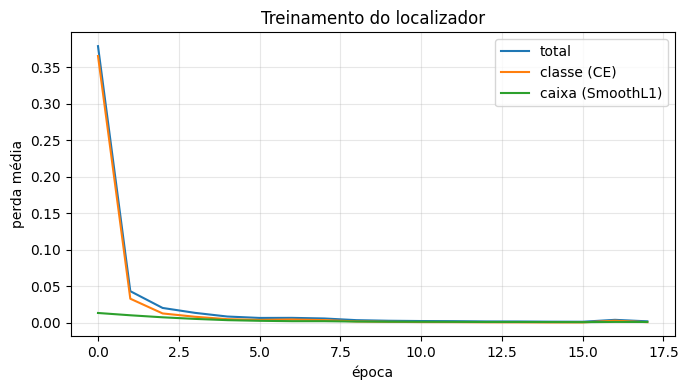

In [10]:
# ============================================================
# 10. Curva de perda
# ============================================================
plt.figure(figsize=(7, 4))
plt.plot(historico_total, label="total")
plt.plot(historico_cls, label="classe (CE)")
plt.plot(historico_box, label="caixa (SmoothL1)")
plt.xlabel("época")
plt.ylabel("perda média")
plt.title("Treinamento do localizador")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [11]:
# ============================================================
# 11. Avaliação: acurácia da classe e IoU médio
# ============================================================
@torch.no_grad()
def avaliar(modelo, loader, tamanho_img: int):
    modelo.eval()
    n_total, n_acertos = 0, 0
    soma_iou = 0.0
    for xb, yb_cls, yb_box in loader:
        xb = xb.to(device); yb_cls = yb_cls.to(device); yb_box = yb_box.to(device)
        logits, caixa_prev = modelo(xb)
        previsao = logits.argmax(dim=1)
        n_acertos += (previsao == yb_cls).sum().item()
        n_total += xb.size(0)
        # Converte cxcywh normalizado -> xyxy em pixels para calcular IoU
        prev_px = cxcywh_para_xyxy(caixa_prev * tamanho_img)
        real_px = cxcywh_para_xyxy(yb_box * tamanho_img)
        ious = iou(prev_px, real_px)
        soma_iou += ious.sum().item()
    return n_acertos / n_total, soma_iou / n_total


acc, iou_medio = avaliar(modelo, dl_teste, tamanho_img=ds_teste.tamanho)
print(f"Acurácia de classe (teste): {acc * 100:.2f}%")
print(f"IoU médio (teste):          {iou_medio:.4f}")

Acurácia de classe (teste): 100.00%
IoU médio (teste):          0.4990


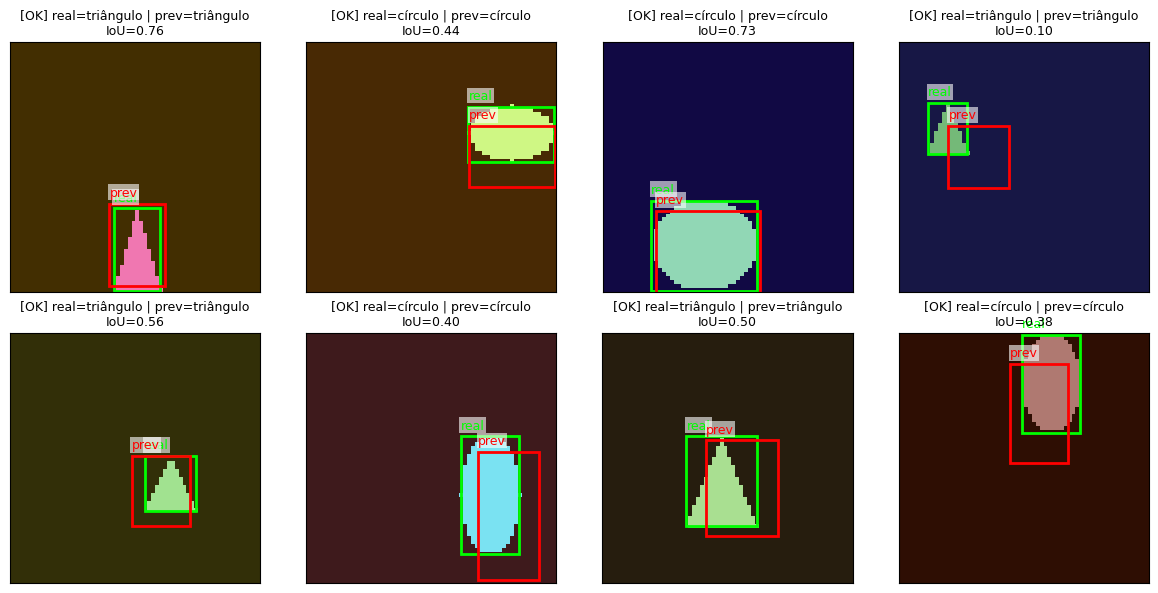

In [12]:
# ============================================================
# 12. Visualização qualitativa: real (verde) vs. prevista (vermelha)
# ============================================================
modelo.eval()
indices = np.random.choice(len(ds_teste), size=8, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
T = ds_teste.tamanho
for ax, idx in zip(axes.flat, indices):
    img, cls_real, caixa_real = ds_teste[idx]
    with torch.no_grad():
        logits, caixa_prev = modelo(img.unsqueeze(0).to(device))
    cls_prev = logits.argmax(dim=1).item()
    caixa_prev = caixa_prev[0].cpu()
    real_px = cxcywh_para_xyxy(caixa_real * T)
    prev_px = cxcywh_para_xyxy(caixa_prev * T)
    iou_val = iou(real_px, prev_px).item()

    ax.imshow(np.clip(img.permute(1, 2, 0).numpy(), 0, 1))
    desenhar_caixa(ax, real_px, "lime", "real")
    desenhar_caixa(ax, prev_px, "red", "prev")
    nome_real = DatasetObjetoUnico.NOMES_CLASSE[cls_real.item()]
    nome_prev = DatasetObjetoUnico.NOMES_CLASSE[cls_prev]
    ok = "OK" if cls_prev == cls_real.item() else "X"
    ax.set_title(f"[{ok}] real={nome_real} | prev={nome_prev}\nIoU={iou_val:.2f}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## Exercício

Investigue o impacto do peso `lambda` que equilibra a perda de classe e a perda de caixa.

In [13]:
# TODO Exercício 1: re-treine com lambda=0.1 e lambda=10 e compare o IoU medio.
# Escreva sua conclusao em comentario abaixo.
#
# Dica: encapsule o treino numa função treinar(lam, epocas=10) que devolve
# (acc, iou_medio) usando ds_treino/ds_teste já criados acima.
#
# Sua conclusão (em comentário):
# ...

## 13. E se houver N objetos? O limite do localizador

O nosso `Localizador` tem **saída de tamanho fixo**: um vetor de classes e
quatro coordenadas. Ele consegue prever **um** objeto, não importa quantos
realmente apareçam na imagem. Vamos comprovar isso na prática.

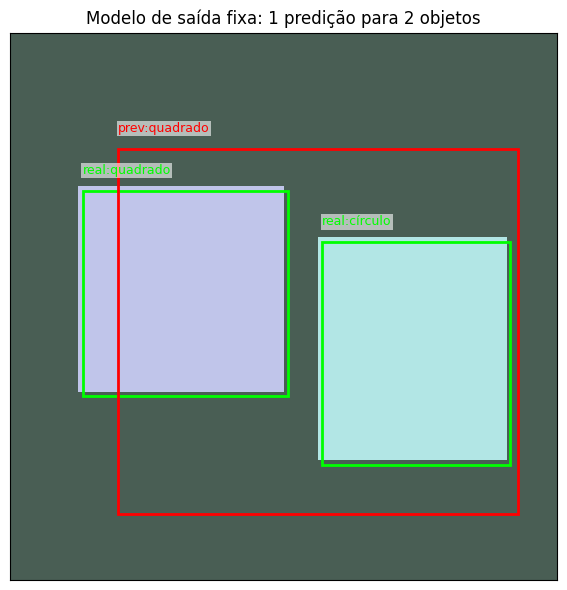

Objetos REAIS: 2  -- classes [0, 1]
Caixas PREVISTAS: 1 (saída fixa do modelo)


In [14]:
# Compõe uma imagem 64x64 com DOIS objetos lado a lado.
def imagem_com_n_objetos(seed: int = 7):
    rng = np.random.default_rng(seed)
    tam = 64
    cor_fundo = rng.uniform(0.1, 0.4, size=3)
    img = np.tile(cor_fundo.reshape(3, 1, 1), (1, tam, tam)).astype(np.float32)
    # objeto 1: lado esquerdo (classe 0 = quadrado)
    img[:, 18:42, 8:32] = rng.uniform(0.7, 0.95, size=(3, 1, 1))
    # objeto 2: lado direito (classe 1 = circulo, aqui aproximado como retangulo colorido)
    img[:, 24:50, 36:58] = rng.uniform(0.7, 0.95, size=(3, 1, 1))
    caixas_reais = [(8, 18, 32, 42), (36, 24, 58, 50)]
    classes_reais = [0, 1]
    return torch.from_numpy(img), caixas_reais, classes_reais


img_n, caixas_reais, classes_reais = imagem_com_n_objetos()

# Roda o localizador (a saida e SEMPRE 1 classe + 1 caixa)
modelo.eval()
with torch.no_grad():
    logits, caixa_norm = modelo(img_n.unsqueeze(0).to(device))
cls_prev = logits.argmax(dim=1).item()
caixa_prev_px = cxcywh_para_xyxy(caixa_norm[0].cpu() * 64)

# Visualiza
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(np.clip(img_n.permute(1, 2, 0).numpy(), 0, 1))
for c, k in zip(caixas_reais, classes_reais):
    nome = DatasetObjetoUnico.NOMES_CLASSE[k]
    desenhar_caixa(ax, torch.tensor(c, dtype=torch.float), "lime", f"real:{nome}")
desenhar_caixa(ax, caixa_prev_px, "red", f"prev:{DatasetObjetoUnico.NOMES_CLASSE[cls_prev]}")
ax.set_title(f"Modelo de saída fixa: 1 predição para 2 objetos")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

print(f"Objetos REAIS: {len(caixas_reais)}  -- classes {classes_reais}")
print(f"Caixas PREVISTAS: 1 (saída fixa do modelo)")

### O que aconteceu

O modelo tem **uma única** cabeça de classe e **uma única** cabeça de caixa.
Diante de vários objetos ele só pode fazer uma de três coisas (todas erradas):

- apontar para apenas **um** dos objetos
- tentar **abranger todos** com uma caixa enorme
- **confundir** classes (compromisso entre quadrado e círculo)

Esse é o motivo pelo qual precisamos sair da abordagem "1 cabeça fixa" e ir para
uma rede de **detecção** que produza caixas em **número variável** — exatamente
o que veremos nos notebooks **02** (Faster R-CNN) e **03** (YOLO).

## Resumo e próximos passos

- Aprendemos as **representações de caixa** (`xyxy` e `cxcywh`, em pixels e normalizadas) e como converter entre elas.
- Implementamos e visualizamos a métrica **IoU**, a régua padrão para qualidade de localização.
- Treinamos do zero um **CNN com duas cabeças** que prevê classe e caixa simultaneamente em imagens sintéticas, com perda multi-tarefa CE + SmoothL1.
- Avaliamos com **acurácia** e **IoU médio**, e inspecionamos resultados qualitativamente.
- O cenário foi simplificado para **um objeto por imagem**; no próximo notebook avançamos para **múltiplos objetos** com um detector real.

Próximo: **`02_deteccao_faster_rcnn.ipynb`** — Faster R-CNN pré-treinado, *anchors*, NMS e detecção em imagens reais.